# Measurement
1. Spectroscopy - goal: resonant freq 
2. separate 0/1, goal: dispersive shift
3. qubit spectroscopy - find qubit mode, power rabi & time rabi (calibrate pi gate) 
4. T1 & Ramsey (T2*) & spin echo(T2) & CPMG (T2)
automation ends
(input of automation: gates, hence need power & time)
5. find the precise qubit freq & pi gate
----- qubit cali ends-----

6. S/ T gates etc or two qubit gate


### Initialization

In [1]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import laboneq
from datetime import datetime

print(laboneq.__version__)

2.51.0


In [2]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.24 16:45:47.996] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.24 16:45:47.998] INFO    VERSION: laboneq 2.51.0
[2025.08.24 16:45:48.000] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.24 16:45:48.007] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.24 16:45:48.011] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.24 16:45:48.015] INFO    Configuring the device setup
[2025.08.24 16:45:48.023] INFO    The device setup is configured


In [ ]:
class resonator_spec:
    """
    Two-stage resonator spectroscopy helper.

    STAGE 1: overall_spec_*  (coarse sweep; find dips; no fitting required)
        - overall_spec_run()
        - overall_spec_analyze()
        - overall_spec_plot()

    STAGE 2: individual_spec_* (per-dip fine sweep + magnitude-only notch fit)
        - individual_spec_run_and_fit()
        - individual_spec_plot()
    """

    # -------------------------- #
    # Construction & parameters  #
    # -------------------------- #
    def __init__(
        self,
        *,
        device_setup,
        session,
        center_freq: float,
        start_freq: float,
        stop_freq: float,
        num_points: int,
        integration_time: float,
        num_averages: int,
        measure_range: float,
        measure_amp: float,
        acquire_range: float,
        acquire_amp: float,
        qubit: str = "q0",
        outdir: str = "resonator_results",
        results_prefix: str | None = None,
    ):
        self.device_setup = device_setup
        self.session = session

        # Coarse sweep params (overall_spec)
        self.center_freq = float(center_freq)
        self.start_freq = float(start_freq)
        self.stop_freq = float(stop_freq)
        self.num_points = int(num_points)
        self.integration_time = float(integration_time)
        self.num_averages = int(num_averages)

        # Signal calibration
        self.measure_range = float(measure_range)
        self.measure_amp = float(measure_amp)
        self.acquire_range = float(acquire_range)
        self.acquire_amp = float(acquire_amp)

        self.qubit = str(qubit)

        # I/O and naming
        self.outdir = Path(outdir); self.outdir.mkdir(parents=True, exist_ok=True)
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.results_prefix = results_prefix or f"res_spec_{ts}"

        # --- Stage 1 containers ---
        self._overall_freq_sweep = None
        self._overall_exp = None
        self._overall_compiled = None
        self._overall_result = None

        self.freq_list = None         # Hz (coarse)
        self.amp = None               # complex (coarse)
        self.amp_dbm = None
        self.phase_rad = None
        self.phase_rad_detrended = None
        self.dips_freq = None         # Hz
        self.dips_amp_dbm = None

        # --- Stage 2 containers ---
        self.individual_runs = []     # list of dicts, one per target

    # -------------------------- #
    # Shared building blocks     #
    # -------------------------- #
    def _make_signal_map(self):
        return {
            "measure": self.device_setup.logical_signal_groups[self.qubit].logical_signals["measure_line"],
            "acquire": self.device_setup.logical_signal_groups[self.qubit].logical_signals["acquire_line"],
        }

    def _make_calibration(self, frequency_source):
        calib = Calibration()
        calib["measure"] = SignalCalibration(
            oscillator=Oscillator(uid="qa_osc_0", frequency=frequency_source, modulation_type=ModulationType.HARDWARE),
            local_oscillator=Oscillator(uid="qa_lo", frequency=self.center_freq),
            range=self.measure_range,
            amplitude=self.measure_amp,
        )
        calib["acquire"] = SignalCalibration(range=self.acquire_range, amplitude=self.acquire_amp)
        return calib

    def _build_experiment(self, freq_sweep, uid="Resonator Spectroscopy", integration_time=None, num_averages=None):
        exp = Experiment(uid=uid, signals=[ExperimentSignal("measure"), ExperimentSignal("acquire")])
        with exp.acquire_loop_rt(
            uid="shots",
            count=pow(2, int(num_averages if num_averages is not None else self.num_averages)),
            acquisition_type=AcquisitionType.SPECTROSCOPY,
        ):
            with exp.sweep(uid="res_freq", parameter=freq_sweep):
                with exp.section(uid="spectroscopy"):
                    exp.acquire(
                        signal="acquire",
                        handle="res_spec",
                        length=float(integration_time if integration_time is not None else self.integration_time),
                    )
                with exp.section(uid="relax", length=100e-6):
                    exp.reserve(signal="measure"); exp.reserve(signal="acquire")
        return exp

    # ========================== #
    # STAGE 1: overall_spec_*    #
    # ========================== #
    def overall_spec_run(self, save_pulse_sheet: bool = False):
        """(overall_spec) Run a single coarse sweep across [start, stop] relative to LO."""
        self._overall_freq_sweep = LinearSweepParameter(
            uid=f"{self.qubit}_res_freq_overall",
            start=self.start_freq,
            stop=self.stop_freq,
            count=self.num_points,
            axis_name="Frequency [Hz]",
        )

        self._overall_exp = self._build_experiment(
            self._overall_freq_sweep, uid="Resonator Spectroscopy (overall_spec)"
        )
        self._overall_exp.set_calibration(self._make_calibration(self._overall_freq_sweep))
        self._overall_exp.set_signal_map(self._make_signal_map())

        self._overall_compiled = self.session.compile(self._overall_exp)

        if save_pulse_sheet:
            Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
            show_pulse_sheet(str(self.outdir / f"{self.results_prefix}_overall_spec_pulsesheet"), self._overall_compiled)

        self._overall_result = self.session.run(self._overall_compiled)
        return self._overall_result

    def overall_spec_analyze(self, dips_to_take: int = 6):
        """(overall_spec) Find dips, compute dBm & detrended phase. No fitting here."""
        if self._overall_result is None:
            raise RuntimeError("overall_spec_run() first.")

        amp = np.asarray(self._overall_result.acquired_results["res_spec"].data).ravel()
        freqs = np.asarray(self._overall_result.acquired_results["res_spec"].axis[0]).ravel()

        freq_list = freqs.astype(float) + float(self.center_freq)
        amplitude = np.abs(amp)
        power_W = (amplitude**2) / 50.0
        amp_dbm = 10.0 * np.log10(power_W / 1e-3)

        order = np.argsort(freq_list)
        freq_list = freq_list[order]
        amp = amp[order]
        amp_dbm = amp_dbm[order]

        phase_rad = np.unwrap(np.arctan2(amp.imag, amp.real))

        f_ghz = freq_list / 1e9
        f0 = f_ghz - f_ghz.mean()

        # mask out bad points
        mask_fin = np.isfinite(f0) & np.isfinite(phase_rad)
        x = f0[mask_fin]
        y = phase_rad[mask_fin]

        if x.size >= 2 and np.ptp(x) > 0:
            try:
                slope_c, intercept = np.polyfit(x, y, 1)
            except np.linalg.LinAlgError:
                # fallback: only remove a constant if fit fails
                slope_c, intercept = 0.0, float(np.median(y))
        else:
            # too few or degenerate points → constant-only detrend
            slope_c, intercept = 0.0, float(np.median(y))

        phase_rad_detrended = phase_rad - (slope_c * f0 + intercept)

        # candidate dips
        def _cand_minima(y): return np.where((y[1:-1] <= y[:-2]) & (y[1:-1] <= y[2:]))[0] + 1
        try:
            from scipy.signal import find_peaks
            inv = -amp_dbm
            peaks, _ = find_peaks(inv, prominence=0.2, distance=max(1, len(inv)//200))
            cand_idx = peaks if len(peaks) else _cand_minima(amp_dbm)
        except Exception:
            cand_idx = _cand_minima(amp_dbm)
        if len(cand_idx) == 0:
            cand_idx = np.array([int(np.argmin(amp_dbm))])

        take = min(dips_to_take, len(cand_idx))
        deep_order = np.argsort(amp_dbm[cand_idx])[:take]
        dips_idx = cand_idx[deep_order]

        # quadratic refinement
        dips_freq, dips_amp = [], []
        for i in dips_idx:
            f_est, a_est = freq_list[i], amp_dbm[i]
            if 0 < i < len(freq_list)-1:
                x = freq_list[i-1:i+2]; y = amp_dbm[i-1:i+2]
                qa, qb, qc = np.polyfit(x, y, 2)
                if qa > 0:
                    f_v = -qb/(2*qa)
                    if x[0] <= f_v <= x[2]:
                        f_est = f_v; a_est = qa*f_v**2 + qb*f_v + qc
            dips_freq.append(f_est); dips_amp.append(a_est)

        dips_freq = np.array(dips_freq); dips_amp = np.array(dips_amp)
        srt = np.argsort(dips_freq); dips_freq = dips_freq[srt]; dips_amp = dips_amp[srt]

        # store
        self.freq_list = freq_list
        self.amp = amp
        self.amp_dbm = amp_dbm
        self.phase_rad = phase_rad
        self.phase_rad_detrended = phase_rad_detrended
        self.dips_freq = dips_freq
        self.dips_amp_dbm = dips_amp

        # save CSVs (overall_spec)
        np.savetxt(self.outdir / f"{self.results_prefix}_overall_spec_amplitude.csv",
                   np.column_stack([self.freq_list, self.amp_dbm]), delimiter=",",
                   header="freq_Hz, amplitude_dBm")
        np.savetxt(self.outdir / f"{self.results_prefix}_overall_spec_phase.csv",
                   np.column_stack([self.freq_list, self.phase_rad_detrended, self.phase_rad]),
                   delimiter=",", header="freq_Hz, phase_rad_detrended, phase_rad")

        return {
            "freq_list_Hz": self.freq_list,
            "amp_complex": self.amp,
            "amp_dbm": self.amp_dbm,
            "phase_rad": self.phase_rad,
            "phase_rad_detrended": self.phase_rad_detrended,
            "dips_freq_Hz": self.dips_freq,
            "dips_amp_dbm": self.dips_amp_dbm,
        }

    def overall_spec_plot(self, save_png: bool = True):
        """(overall_spec) Plot coarse amplitude/phase with dip markers."""
        if any(x is None for x in [self.freq_list, self.amp_dbm, self.phase_rad_detrended, self.dips_freq]):
            raise RuntimeError("overall_spec_analyze() first.")
        fGHz = self.freq_list / 1e9; dipsGHz = self.dips_freq / 1e9

        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(9, 6), sharex=True, gridspec_kw={'height_ratios': [1.5, 1.0]}
        )
        ax1.plot(fGHz, self.amp_dbm, "-")
        ax1.set_ylabel("Amplitude [dBm]")
        ax1.set_title("Resonator Spectroscopy")
        for f_min_GHz, a_min in zip(dipsGHz, self.dips_amp_dbm):
            ax1.scatter([f_min_GHz], [a_min], marker="x", s=90, zorder=5)
            ax1.axvline(x=f_min_GHz, linestyle="--", alpha=0.35)
            ax1.annotate(f"{f_min_GHz:.4f} GHz", (f_min_GHz, a_min),
                         textcoords="offset points", xytext=(6, 8), fontsize=8)

        ax2.plot(fGHz, self.phase_rad_detrended, "-", color="tab:purple")
        for f_min_GHz in dipsGHz:
            ax2.axvline(x=f_min_GHz, linestyle="--", alpha=0.35)
        ax2.set_xlabel("Frequency [GHz]"); ax2.set_ylabel("Phase [rad]")
        plt.tight_layout()

        png = None
        if save_png:
            png = self.outdir / f"{self.results_prefix}_overall_spec.png"
            fig.savefig(png, dpi=600)
        return fig, {"png": str(png) if png else None}

    # ============================== #
    # STAGE 2: individual_spec_*     #
    # ============================== #

    # --- Notch-model (no cable delay) ---
    def _s21_notch_complex(self, f, fr, Ql, Qc_mag, phi, a_mag):
        """
        Complex S21(f) for a notch resonator (no delay/offset):
          S21(f) = a * [ 1 - (Ql/Qc_mag) * e^{i phi} / (1 + 2i Ql (f/fr - 1)) ]
        """
        x   = (f / fr) - 1.0
        num = (Ql / Qc_mag) * np.exp(1j * phi)
        den = 1.0 + 2j * Ql * x
        return a_mag * (1.0 - num / den)

    def _s21_notch_mag(self, f, fr, Ql, Qc_mag, phi, a_mag):
        return np.abs(self._s21_notch_complex(f, fr, Ql, Qc_mag, phi, a_mag))

    def _guess_notch_params(self, f_Hz, y_mag):
        """Heuristic initial guesses from |S21| dip."""
        hi = np.partition(y_mag, int(0.8*len(y_mag)))[int(0.8*len(y_mag)):]
        a0 = float(np.median(hi)) if len(hi) else float(np.median(y_mag))
        a0 = max(a0, 1e-12)

        i_min = int(np.argmin(y_mag))
        fr0  = float(f_Hz[i_min])
        ymin = float(y_mag[i_min])

        depth = np.clip(1.0 - ymin / a0, 1e-4, 0.99)

        # crude FWHM → Ql
        span_idx = max(3, len(f_Hz)//40)
        left  = max(i_min - span_idx, 0)
        right = min(i_min + span_idx, len(f_Hz)-1)
        mid = ymin + 0.5*(a0 - ymin)
        try: left  = np.argmin(np.abs(y_mag[:i_min] - mid))
        except: pass
        try: right = i_min + np.argmin(np.abs(y_mag[i_min:] - mid))
        except: pass

        fwhm = max(f_Hz[right] - f_Hz[left], max(fr0 * 1e-6, np.finfo(float).eps))
        Ql0  = float(abs(fr0 / fwhm))
        Qc0  = float(Ql0 / depth)
        phi0 = 0.0

        # clamps
        fr0 = max(fr0, 1.0)
        Ql0 = float(np.clip(Ql0, 1e2, 1e9))
        Qc0 = float(np.clip(Qc0, 1e2, 1e12))
        a0  = float(np.clip(a0, 1e-12, 1e6))
        return fr0, Ql0, Qc0, phi0, a0

    def _fit_notch_magnitude(self, f_Hz, y_mag, guess=None):
        """
        Fit |S21| with the notch model; returns dict {fr, Ql, Qc_mag, phi, a, cov, method}.
        """
        if guess is None:
            guess = self._guess_notch_params(f_Hz, y_mag)

        try:
            from scipy.optimize import curve_fit
            lower = [min(f_Hz)*0.5, 1e2, 1e2, -np.pi, 1e-12]
            upper = [max(f_Hz)*1.5, 1e9, 1e12, np.pi, 1e6]
            popt, pcov = curve_fit(
                lambda f, fr, Ql, Qc_mag, phi, a: self._s21_notch_mag(f, fr, Ql, Qc_mag, phi, a),
                f_Hz, y_mag, p0=guess, bounds=(lower, upper), maxfev=30000
            )
            fr, Ql, Qc_mag, phi, a = map(float, popt)
            return {"fr": fr, "Ql": abs(Ql), "Qc_mag": abs(Qc_mag), "phi": phi, "a": abs(a), "cov": pcov, "method": "scipy"}
        except Exception:
            # grid fallback
            fr0, Ql0, Qc0, phi0, a0 = guess
            fr_grid  = np.linspace(fr0*0.999, fr0*1.001, 15)
            Ql_grid  = np.linspace(max(1e2, Ql0/4),  min(1e9,  Ql0*4),  15)
            Qc_grid  = np.linspace(max(1e2, Qc0/4),  min(1e12, Qc0*4), 12)
            phi_grid = np.linspace(-0.5*np.pi, 0.5*np.pi, 11)
            a_grid   = np.linspace(max(1e-12, a0/3),   min(1e6,  a0*3),  10)
            best = None; best_err = np.inf
            for fr_ in fr_grid:
                for Ql_ in Ql_grid:
                    for Qc_ in Qc_grid:
                        for phi_ in phi_grid:
                            base = self._s21_notch_mag(f_Hz, fr_, Ql_, Qc_, phi_, 1.0)
                            for a_ in a_grid:
                                y_pred = a_ * (base / np.max(base))  # simple scaling
                                err = np.mean((y_mag - y_pred)**2)
                                if err < best_err:
                                    best_err = err; best = (fr_, Ql_, Qc_, phi_, a_)
            fr, Ql, Qc_mag, phi, a = best
            return {"fr": float(fr), "Ql": float(abs(Ql)), "Qc_mag": float(abs(Qc_mag)),
                    "phi": float(phi), "a": float(abs(a)), "cov": None, "method": "grid"}

    # --- Fine sweep ---
    def _run_single_fine_sweep(self, center_Hz, span_Hz, points, integration_time, num_averages):
        """
        Build/compile/run a single fine sweep around `center_Hz` ± span_Hz/2 relative to LO.
        """
        rel_center = float(center_Hz - self.center_freq)
        start = rel_center - span_Hz/2
        stop  = rel_center + span_Hz/2

        sweep = LinearSweepParameter(
            uid=f"{self.qubit}_indiv_freq_{int(center_Hz)}",
            start=start, stop=stop, count=int(points), axis_name="Frequency [Hz]"
        )
        exp = self._build_experiment(
            sweep,
            uid=f"Resonator Spectroscopy (individual_spec @ {center_Hz/1e9:.6f} GHz)",
            integration_time=integration_time,
            num_averages=num_averages,
        )
        exp.set_calibration(self._make_calibration(sweep))
        exp.set_signal_map(self._make_signal_map())

        compiled = self.session.compile(exp)
        result = self.session.run(compiled)

        # Extract & convert to absolute frequencies
        amps = np.asarray(result.acquired_results["res_spec"].data).ravel()
        frel = np.asarray(result.acquired_results["res_spec"].axis[0]).ravel()
        fabs = frel.astype(float) + float(self.center_freq)

        # Magnitude and (optional) dBm
        amplitude = np.abs(amps)
        power_W   = (amplitude**2)/50.0
        y_dbm     = 10.0*np.log10(power_W/1e-3)
        y_mag     = amplitude

        return {"center_Hz": center_Hz, "span_Hz": span_Hz, "points": points,
                "result": result, "freq_Hz": fabs, "amp_complex": amps,
                "amp_dBm": y_dbm, "amp_mag": y_mag}

    def individual_spec_run_and_fit(
        self,
        fine_span_Hz: float = 2e6,
        fine_points: int = 801,
        fine_integration_time: float = None,
        fine_num_averages: int = None,
        targets_Hz: np.ndarray | list | None = None,
    ):
        """
        (individual_spec) For each target frequency, do a fine sweep and fit |S21| magnitude.
        """
        if targets_Hz is None:
            if self.dips_freq is None:
                raise RuntimeError("No targets. Run overall_spec_analyze() or pass targets_Hz.")
            targets_Hz = self.dips_freq

        self.individual_runs = []

        for f0 in np.asarray(targets_Hz, dtype=float):
            run = self._run_single_fine_sweep(
                center_Hz=f0,
                span_Hz=float(fine_span_Hz),
                points=int(fine_points),
                integration_time=(self.integration_time if fine_integration_time is None else float(fine_integration_time)),
                num_averages=(self.num_averages if fine_num_averages is None else int(fine_num_averages)),
            )
            # Magnitude-only fit
            fit = self._fit_notch_magnitude(run["freq_Hz"], run["amp_mag"])

            # Derived internal Q (guard against division by zero)
            Qi = None
            try:
                Qi = float(1.0 / (1.0/fit["Ql"] - 1.0/fit["Qc_mag"]))
                if not np.isfinite(Qi): Qi = None
            except Exception:
                Qi = None
            fit["Qi"] = Qi

            run["fit"] = fit
            self.individual_runs.append(run)

        # Save per-dip CSV and summary (use q1..qn)
        rows = []
        for k, run in enumerate(self.individual_runs, start=1):
            q_label = f"q{k}"
            run["q_label"] = q_label

            freq  = run["freq_Hz"]
            y_lin = run["amp_mag"]
            y_dbm = run["amp_dBm"]

            prefix = self.outdir / f"{self.results_prefix}_res_spec_{q_label}"
            np.savetxt(
                f"{prefix}_individual_spec.csv",
                np.column_stack([freq, y_lin, y_dbm]),
                delimiter=",",
                header="freq_Hz, abs_amp(|S21|), amplitude_dBm",
            )

            ffit = run["fit"]
            rows.append([
                q_label, k, run["center_Hz"],
                ffit["fr"], ffit["Ql"], ffit["Qc_mag"], ffit["Qi"], ffit["phi"], ffit["a"], ffit["method"]
            ])

        if rows:
            np.savetxt(
                self.outdir / f"{self.results_prefix}_individual_spec_fits.csv",
                np.array(rows, dtype=object), fmt="%s", delimiter=",",
                header="q_label, peak_index, center_Hz_request, fr_fit_Hz, Ql, Qc_mag, Qi, phi_rad, a_mag, method",
            )

        return self.individual_runs
    def _fmt_Q(self, Q):
        if Q is None or not np.isfinite(Q):
            return r"$\mathrm{N/A}$"
        if Q >= 1e6:
            return f"{Q/1e6:.2f}M"
        elif Q >= 1e3:
            return f"{Q/1e3:.1f}k"
        else:
            return f"{Q:.0f}"
    def individual_spec_plot(self, save_png: bool = True):
        """
        (individual_spec) Plot |S21| in dBm + phase (data detrended, model raw);
        data as 'o' markers; mag:phase height ratio = 1.5:1.
        """
        if not self.individual_runs:
            raise RuntimeError("Run individual_spec_run_and_fit() first.")

        figs = []; metas = []
        for k, run in enumerate(self.individual_runs, start=1):
            f     = run["freq_Hz"]
            ymag  = run["amp_mag"]        # linear |S21|
            amps  = run["amp_complex"]
            fit   = run["fit"]
            q_lbl = run.get("q_label", f"q{k}")

            # Model predictions from magnitude-fit params (no delay terms)
            s21_fit  = self._s21_notch_complex(f, fit["fr"], fit["Ql"], fit["Qc_mag"], fit["phi"], fit["a"])
            ymag_fit = np.abs(s21_fit)

            # ---- Convert linear amplitude -> dBm (inline; assumes 50 Ω) ----
            power_W_data = (np.asarray(ymag)     ** 2) / 50.0
            power_W_fit  = (np.asarray(ymag_fit) ** 2) / 50.0
            # avoid -inf from log(0)
            y_dbm_data = 10.0 * np.log10(np.maximum(power_W_data, 1e-20) / 1e-3)
            y_dbm_fit  = 10.0 * np.log10(np.maximum(power_W_fit,  1e-20) / 1e-3)

            # Phase (unwrap data and model)
            phase_data = np.unwrap(np.arctan2(amps.imag, amps.real))
            phase_fit  = np.unwrap(np.arctan2(s21_fit.imag, s21_fit.real))

            # Detrend phase on edges outside ±k*FWHM
            fr   = fit["fr"]; Ql = fit["Ql"]
            fwhm = fr / Ql
            k_exclude = 2.0
            mask = (f < fr - k_exclude*fwhm) | (f > fr + k_exclude*fwhm)

            fGHz = f / 1e9
            f0   = fGHz - fGHz.mean()
            slope, intercept = np.polyfit(f0[mask], phase_data[mask], 1)
            phase_data_dt = phase_data - (slope*f0 + intercept)

            # Legend text (compact Q formatting you already have)
            Qi = fit.get("Qi")
            legend_txt = (
                rf"$f_{{r}} = {fit['fr']/1e9:.6f}\,\mathrm{{GHz}}$" + "\n" +
                rf"$Q_{{i}} = {self._fmt_Q(Qi)}$" + "\n" +
                rf"$Q_{{c}} = {self._fmt_Q(fit['Qc_mag'])}$" + "\n" +
                rf"$Q_{{l}} = {self._fmt_Q(fit['Ql'])}$"
            )

            # Figure with two stacked subplots (mag:phase = 1.5:1)
            fig, (ax1, ax2) = plt.subplots(
                2, 1, figsize=(6.75, 4.5), sharex=True,
                gridspec_kw={'height_ratios': [1.5, 1.0]}
            )

            # Magnitude subplot (now in dBm)
            ax1.plot(fGHz, y_dbm_data, "o", label="|S21| data", markersize=3)
            ax1.plot(fGHz, y_dbm_fit,  "--", label=legend_txt)
            ax1.set_ylabel("|S21| [dBm]")
            ax1.set_title(f"Resonator Spectroscopy — individual_spec (Q{k})")
            ax1.legend(fontsize=8, loc="best")

            # Phase subplot
            ax2.plot(fGHz, phase_data_dt, "o", label="phase data", markersize=3)
            ax2.plot(fGHz, phase_fit,    "--", label="phase fit")
            ax2.set_xlabel("Frequency [GHz]")
            ax2.set_ylabel("Phase [rad]")
            ax2.legend(fontsize=8, loc="best")

            plt.tight_layout()

            png = None
            if save_png:
                png = self.outdir / f"{self.results_prefix}_res_spec_{q_lbl}.png"
                fig.savefig(png, dpi=600)
            figs.append(fig); metas.append({"png": str(png) if png else None})

        return figs, metas



    # ============================== #
    # STAGE 3: individual_spec3d_*   #
    # ============================== #

    def _make_calibration_for_3d(self, frequency_source, *, meas_amp_lin, meas_range_db,
                             acq_amp_lin, acq_range_db):
        calib = Calibration()
        calib["measure"] = SignalCalibration(
            oscillator=Oscillator(uid="qa_osc_0", frequency=frequency_source, modulation_type=ModulationType.HARDWARE),
            local_oscillator=Oscillator(uid="qa_lo", frequency=self.center_freq),
            range=float(meas_range_db),
            amplitude=float(meas_amp_lin),
        )
        calib["acquire"] = SignalCalibration(
            range=float(acq_range_db),
            amplitude=float(acq_amp_lin),
        )
        return calib

    def individual_spec3d_run(
        self,
        *,
        dip_index: int | None = 1,
        center_Hz: float | None = None,
        # choose ONE: span_Hz OR span_low_Hz/span_high_Hz
        span_low_Hz: float | None = 2e6,
        span_high_Hz: float | None = 2e6,
        points: int = 201,
        integration_time: float | None = None,
        num_averages: int | None = None,
        measure_amps: np.ndarray | list | None = None,   # amp_list (linear), used in -20log10(amp)
        base_db_offset: float = 0.0,
        edge_points_for_baseline: int = 10,
    ):
        # center
        if center_Hz is None:
            if not (getattr(self, "dips_freq", None) is not None and len(self.dips_freq) > 0):
                raise RuntimeError("No dip info. Provide center_Hz or set self.dips_freq.")
            if dip_index is None or dip_index < 1 or dip_index > len(self.dips_freq):
                raise ValueError(f"dip_index must be in [1, {len(self.dips_freq)}].")
            center_Hz = float(self.dips_freq[dip_index - 1])
        center_Hz = float(center_Hz)


        span_low_Hz = float(span_low_Hz if span_low_Hz is not None else 0.0)
        span_high_Hz = float(span_high_Hz if span_high_Hz is not None else 0.0)

        rel_center = center_Hz - float(self.center_freq)
        start = rel_center + span_low_Hz
        stop  = rel_center + span_high_Hz

        int_time = float(self.integration_time if integration_time is None else integration_time)
        navg     = int(self.num_averages if num_averages is None else num_averages)

        if measure_amps is None:
            raise ValueError("Provide 'measure_amps' (linear amp_list).")
        measure_amps = np.asarray(measure_amps, dtype=float).ravel()
        if measure_amps.size == 0:
            raise ValueError("'measure_amps' is empty.")

        rows_dbnorm  = []
        y_vals_dB    = []
        freqs_abs_Hz = None

        base_meas_amp_lin  = float(self.measure_amp)
        base_acq_amp_lin   = float(self.acquire_amp)

        for a in measure_amps:
            amp_ratio = 10**(-a/20)

            row_meas_amp_lin  = base_meas_amp_lin  * amp_ratio
            row_acq_amp_lin   = base_acq_amp_lin * amp_ratio
            sweep = LinearSweepParameter(
                uid=f"{self.qubit}_3d_freq_{int(center_Hz)}_amp_{a:.2f}dB",
                start=start, stop=stop, count=int(points), axis_name="Frequency [Hz]"
            )

            exp = self._build_experiment(
                sweep,
                uid=f"Res 3D @ {center_Hz/1e9:.6f} GHz (Δ={a:.2f} dB)",
                integration_time=int_time,
                num_averages=navg,
            )
            exp.set_calibration(self._make_calibration_for_3d(
                sweep,
                meas_amp_lin=row_meas_amp_lin,
                meas_range_db=self.measure_range,
                acq_amp_lin=row_acq_amp_lin,
                acq_range_db=self.acquire_range,
            ))
            exp.set_signal_map(self._make_signal_map())

            compiled = self.session.compile(exp)
            result   = self.session.run(compiled)

            amps_cplx = np.asarray(result.acquired_results["res_spec"].data).ravel() #complex amps
            aabs = np.abs(amps_cplx) #absolute amps
            frel      = np.asarray(result.acquired_results["res_spec"].axis[0]).ravel() #relative freqs
            fabs      = frel.astype(float) + float(self.center_freq) #absolute freqs
            if freqs_abs_Hz is None:
                freqs_abs_Hz = fabs

            # Detrend in linear domain using edge points
            n = aabs.size
            EPS = 1e-12
            if edge_points_for_baseline and n >= 4:
                edge_pts  = int(min(max(edge_points_for_baseline, 1), (n - 2)//2))
                left_db   = 20*np.log10(max(np.mean(aabs[:edge_pts]), EPS))
                right_db  = 20*np.log10(max(np.mean(aabs[-edge_pts:]), EPS))
                baseline_db = np.linspace(left_db, right_db, n)
                row_db = 20*np.log10(np.maximum(aabs, EPS)) - baseline_db
            else:
                row_db = 20*np.log10(np.maximum(aabs, EPS))

            rows_dbnorm.append(row_db)


            y_vals_dB.append(base_db_offset + self.measure_range+ 20.0*np.log10(max(row_meas_amp_lin, 1e-12)))
        self._spec3d = {
        "center_Hz": center_Hz,
        "start_Hz": center_Hz + span_low_Hz,
        "stop_Hz":  center_Hz + span_high_Hz,
        "freq_Hz":  freqs_abs_Hz,
        "meas_amp_dB": np.array(y_vals_dB),
        "data_db_norm": np.vstack(rows_dbnorm),
        "measure_amps": measure_amps,
        "integration_time": int_time,
        "num_averages": navg,
        "dip_index": dip_index}

        return self._spec3d

    def individual_spec3d_plot(
        self,
        save_png: bool = True,
        clim: tuple[float, float] | None = None,
        *,
        show_dips: bool = False,
        use_stage1_dips: bool = True,
        dip_freqs_Hz: list | np.ndarray | None = None,
        dip_indices: list[int] | None = None,
        dip_style: dict | None = None,
        y_label: str = "Sweep Amplitude [dB]",
        title: str | None = None,
    ):
        if not hasattr(self, "_spec3d") or self._spec3d is None:
            raise RuntimeError("Run individual_spec3d_run() first.")

        D = self._spec3d
        fGHz = D["freq_Hz"] / 1e9

        fig, ax = plt.subplots(figsize=(6, 4.5))
        pcm = ax.pcolormesh(
            fGHz,
            D["meas_amp_dB"],
            D["data_db_norm"],
            shading="auto",
            cmap="plasma",
        )
        ax.set_xlim(np.min(fGHz), np.max(fGHz))
        ax.set_xlabel("Frequency [GHz]")
        ax.set_ylabel(y_label)
        ax.set_title(title or f"Resonator 3D spec @ {D['center_Hz']/1e9:.6f} GHz")
        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label("ΔSignal [dB]")

        if clim is not None:
            pcm.set_clim(*clim)
        if "two_dip_indices" in D and D["two_dip_indices"] is not None:
            dips_fGHz = (np.asarray(D["two_dip_freqs_Hz"], float) / 1e9)
            # draw dashed white verticals
            for x in dips_fGHz:
                ax.axvline(x, ls="--", lw=1.2, color="white", alpha=0.9)

            # label Δf at mid-x and mid-y of your data extent
            mid_x = float(np.mean(dips_fGHz))
            y_vals = np.asarray(D["meas_amp_dB"], float)
            mid_y = float(np.median(y_vals))
            df_MHz = D["two_dip_delta_Hz"] / 1e6
            ax.text(
                mid_x, mid_y, f"Δf = {df_MHz:.3f} MHz",
                ha="center", va="center",
                fontsize=9,
                bbox=dict(boxstyle="round", fc="0.2", ec="0.9", alpha=0.6, pad=0.3),
                color="white",
            )
        plt.tight_layout()
        png = None
        if save_png:
            png = self.outdir / f"{self.results_prefix}_res_spec3d_Q{dip_index}.png"
            fig.savefig(png, dpi=600)
        return fig, {"png": str(png) if png else None}
    
    def spec3d_find_two_vertical_dips(
        self,
        *,
        percentile: float = 10.0,     # use a low percentile across rows to form a 1-D "darkness" profile
        min_sep_bins: int = 5,        # minimum frequency-bin separation between the two dips
        prominence_db: float = 0.8,   # how deep a dip must be to count (in dB on the profile)
    ) -> dict:
        """
        From self._spec3d, find the two most prominent *vertical* dips (vs frequency).
        Returns a dict with indices, freqs (Hz), and spacing (Hz). Stores the same in self._spec3d.
        """
        if not hasattr(self, "_spec3d") or self._spec3d is None:
            raise RuntimeError("Run individual_spec3d_run() first.")

        D = self._spec3d
        Z = np.asarray(D["data_db_norm"], dtype=float)      # shape: (Ny, Nx)
        f = np.asarray(D["freq_Hz"], dtype=float)           # shape: (Nx,)

        # Build a 1-D profile across rows; lower = darker = deeper dip.
        # No smoothing here (per your preference); percentile is robust to outliers.
        profile = np.percentile(Z, percentile, axis=0).astype(float)  # length Nx

        # Find *minima* by finding peaks on the negated profile
        peaks, props = find_peaks(-profile, distance=max(1, int(min_sep_bins)), prominence=prominence_db)

        if peaks.size < 2:
            # Fallback: take two lowest points with manual separation
            order = np.argsort(profile)  # ascending (most negative/lowest first)
            chosen = []
            for idx in order:
                if not chosen or all(abs(idx - c) >= min_sep_bins for c in chosen):
                    chosen.append(int(idx))
                if len(chosen) == 2:
                    break
            if len(chosen) < 2:
                raise RuntimeError("Could not find two separated vertical dips.")
            dip_idx = np.array(sorted(chosen))
        else:
            # Sort candidate dips by depth (lower profile value first) and keep top two
            best = peaks[np.argsort(profile[peaks])]  # lowest first
            # enforce separation; keep first, then the best that honors min_sep_bins
            dip_idx = [int(best[0])]
            for i in best[1:]:
                if abs(i - dip_idx[0]) >= min_sep_bins:
                    dip_idx.append(int(i))
                    break
            if len(dip_idx) < 2:
                # if the very best two violate separation, try again greedily
                for i in best[2:]:
                    if all(abs(i - j) >= min_sep_bins for j in dip_idx):
                        dip_idx.append(int(i))
                        break
            if len(dip_idx) < 2:
                raise RuntimeError("Found dips but couldn't enforce min_sep_bins.")
            dip_idx = np.array(sorted(dip_idx))

        dip_freqs_Hz = f[dip_idx]
        df_Hz = float(abs(dip_freqs_Hz[1] - dip_freqs_Hz[0]))

        out = {
            "dip_indices": dip_idx.tolist(),
            "dip_freqs_Hz": dip_freqs_Hz.tolist(),
            "delta_f_Hz": df_Hz,
            "profile": profile,   # returned for debugging/inspection
        }

        # cache inside spec3d dict for plotting
        D["two_dip_indices"] = dip_idx
        D["two_dip_freqs_Hz"] = dip_freqs_Hz
        D["two_dip_delta_Hz"] = df_Hz
        D["two_dip_profile_percentile"] = float(percentile)
        return out

## Resonator Spectroscopy

In [4]:
rs = resonator_spec(
    device_setup=device_setup,
    session=session,
    center_freq=7e9,
    start_freq=125e6,
    stop_freq=315e6,
    num_points=2001,
    integration_time=1e-5,
    num_averages=8,
    measure_range=-10,
    measure_amp=0.7,
    acquire_range=-20,
    acquire_amp=0.9,
    qubit="q0",
    outdir="resonator_results",
)

[2025.08.24 16:45:50.909] INFO    Starting LabOne Q Compiler run...
[2025.08.24 16:45:51.295] INFO    Schedule completed. [0.385 s]
[2025.08.24 16:45:52.025] INFO    Code generation completed for all AWGs. [0.729 s]
[2025.08.24 16:45:52.026] INFO    Completed compilation step 1 of 1. [1.115 s]
[2025.08.24 16:45:52.033] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.24 16:45:52.033] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.24 16:45:52.034] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.24 16:45:52.035] INFO      device_shfqc     0         21            0           0         0  
[2025.08.24 16:45:52.036] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.24 16:45:52.036] INFO      TOTAL                      21            0                     0  
[2025.08.24 16:45:52.037] INFO     ────────────────────────────────────────────────────

(<Figure size 900x600 with 2 Axes>,
 {'png': 'resonator_results\\res_spec_20250824_164549_overall_spec.png'})

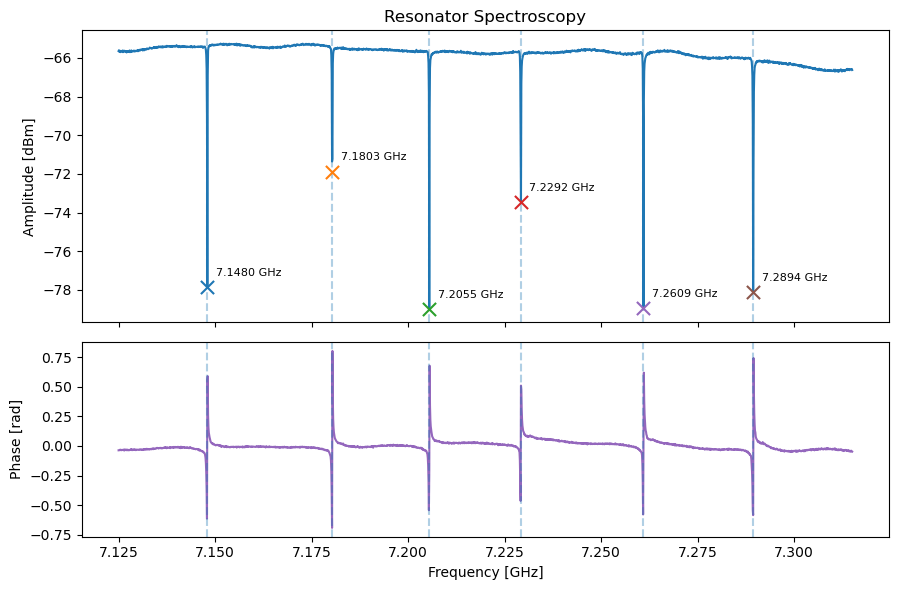

In [5]:
# Stage 1: overall_spec
rs.overall_spec_run(save_pulse_sheet=True)
rs.overall_spec_analyze(dips_to_take=6)
rs.overall_spec_plot(save_png=True)

[2025.08.24 15:19:03.790] INFO    Starting LabOne Q Compiler run...


[2025.08.24 15:19:03.883] INFO    Schedule completed. [0.089 s]
[2025.08.24 15:19:04.002] INFO    Code generation completed for all AWGs. [0.119 s]
[2025.08.24 15:19:04.003] INFO    Completed compilation step 1 of 1. [0.210 s]
[2025.08.24 15:19:04.007] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.24 15:19:04.007] INFO      Device         AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.24 15:19:04.008] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.24 15:19:04.009] INFO      device_shfqc     0         21            0           0         0  
[2025.08.24 15:19:04.009] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.24 15:19:04.010] INFO      TOTAL                      21            0                     0  
[2025.08.24 15:19:04.011] INFO     ────────────────────────────────────────────────────────────────── 
[2025.08.24 15:19:04.014] INFO    Finished LabOne Q 

([<Figure size 675x450 with 2 Axes>,
  <Figure size 675x450 with 2 Axes>,
  <Figure size 675x450 with 2 Axes>,
  <Figure size 675x450 with 2 Axes>,
  <Figure size 675x450 with 2 Axes>,
  <Figure size 675x450 with 2 Axes>],
 [{'png': 'resonator_results\\res_spec_20250824_151608_res_spec_q1.png'},
  {'png': 'resonator_results\\res_spec_20250824_151608_res_spec_q2.png'},
  {'png': 'resonator_results\\res_spec_20250824_151608_res_spec_q3.png'},
  {'png': 'resonator_results\\res_spec_20250824_151608_res_spec_q4.png'},
  {'png': 'resonator_results\\res_spec_20250824_151608_res_spec_q5.png'},
  {'png': 'resonator_results\\res_spec_20250824_151608_res_spec_q6.png'}])

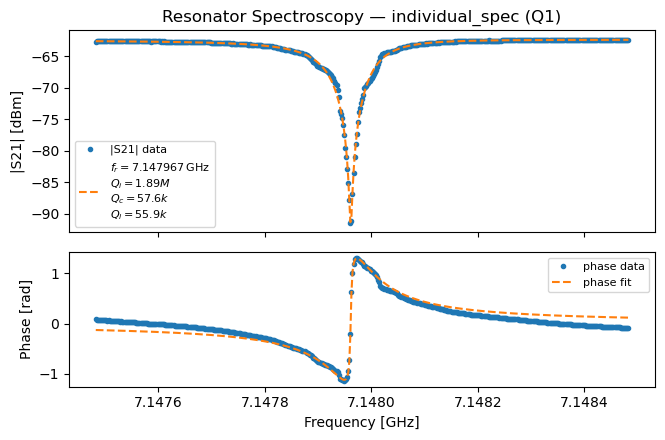

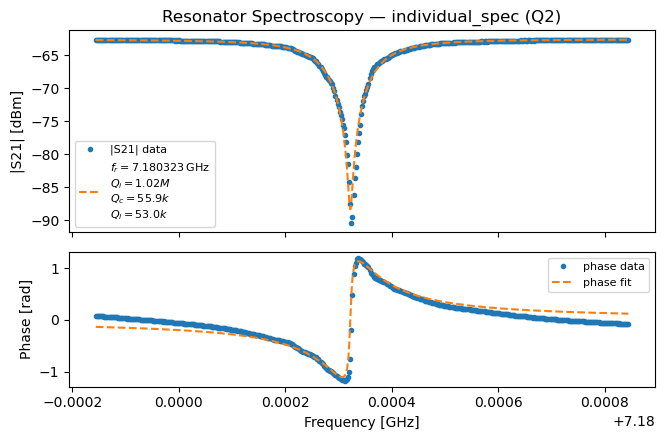

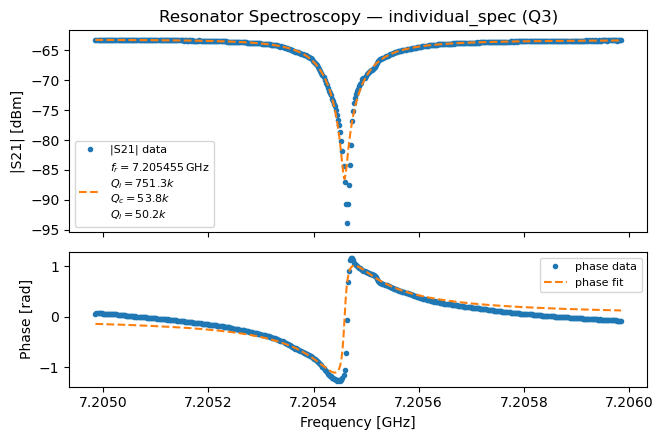

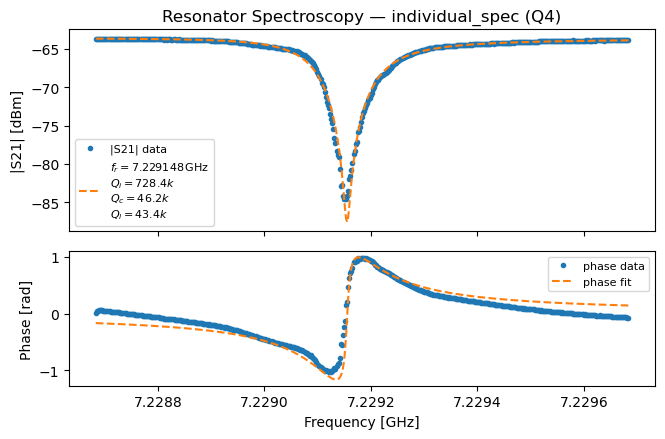

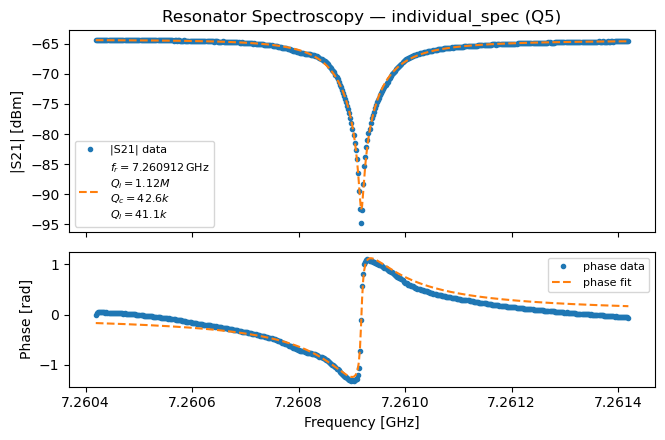

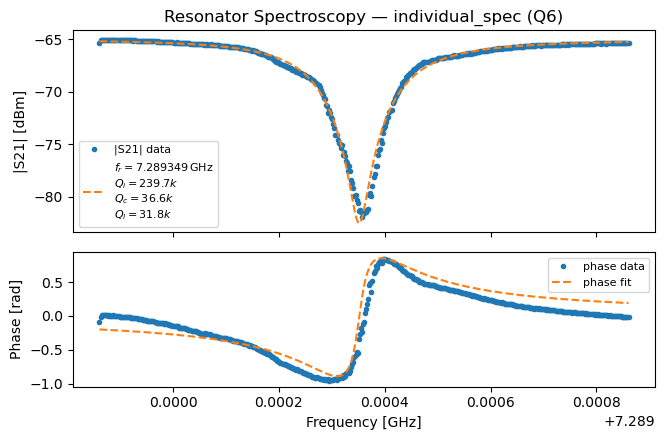

In [15]:
# Stage 2: individual_spec (fine sweeps + Lorentzian fits)
rs.individual_spec_run_and_fit(
    fine_span_Hz=1e6,       # ±1 MHz around each target
    fine_points=501,        # high resolution
    fine_integration_time=1e-5,
    fine_num_averages=9,
)
rs.individual_spec_plot(save_png=True)

[2025.08.24 16:51:33.698] INFO    Starting LabOne Q Compiler run...
[2025.08.24 16:51:33.760] INFO    Schedule completed. [0.060 s]
[2025.08.24 16:51:33.836] WARNING Parameter name 'q0_3d_freq_7180334693_amp_0.00dB' has been sanitized in generated code.
[2025.08.24 16:51:33.836] WARNING Parameter name 'q0_3d_freq_7180334693_amp_0.00dB' has been sanitized in generated code.
[2025.08.24 16:51:33.838] WARNING Parameter name 'q0_3d_freq_7180334693_amp_0.00dB' has been sanitized in generated code.
[2025.08.24 16:51:33.839] WARNING Parameter name 'q0_3d_freq_7180334693_amp_0.00dB' has been sanitized in generated code.
[2025.08.24 16:51:33.840] WARNING Parameter name 'q0_3d_freq_7180334693_amp_0.00dB' has been sanitized in generated code.
[2025.08.24 16:51:33.841] WARNING Parameter name 'q0_3d_freq_7180334693_amp_0.00dB' has been sanitized in generated code.
[2025.08.24 16:51:33.841] WARNING Parameter name 'q0_3d_freq_7180334693_amp_0.00dB' has been sanitized in generated code.
[2025.08.24 16

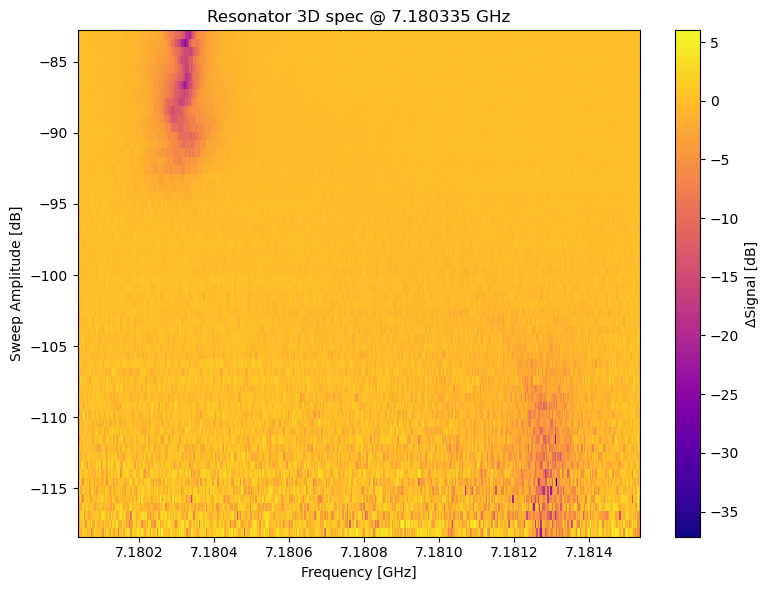

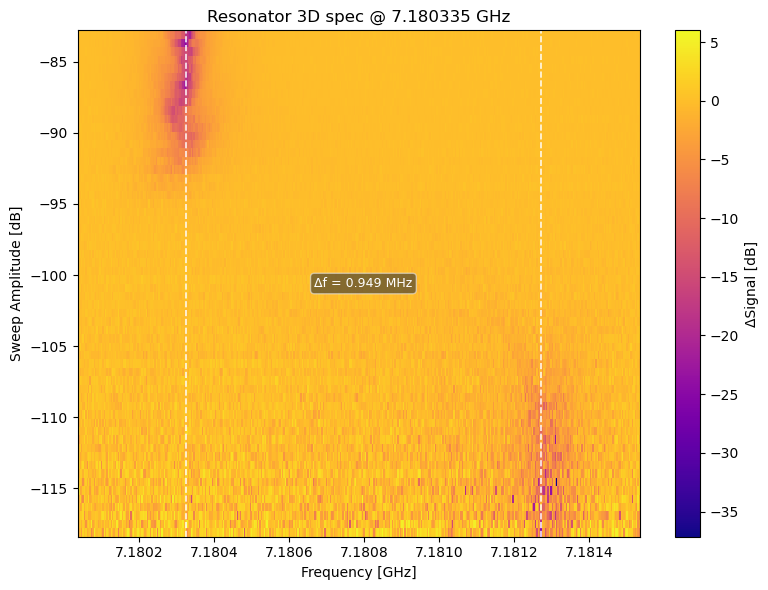

In [7]:
# Stage 3
amp_list = np.linspace(0, 35, 60)  # dB step (additional attenuation per row)

# 1) Run the 3D spec
rs.individual_spec3d_run(
    dip_index=2,                 # or: center_Hz=YOUR_FREQ
    span_low_Hz=-0.3e6,
    span_high_Hz= 1.2e6,
    points=401,
    integration_time=1.5e-5,
    num_averages=5,
    measure_amps=amp_list,       # dB steps; code converts via 10^(-a/20)
    base_db_offset=-70.0,
    edge_points_for_baseline=10,
)

# 2) Save a "base" heatmap (no overlays yet)
fig_base, meta = rs.individual_spec3d_plot(save_png=True)

# 3) Find the two vertical dips (stores results in self._spec3d for plotting)
dipres = rs.spec3d_find_two_vertical_dips(percentile=10, min_sep_bins=5, prominence_db=0.8)

# 4) Re-plot to include dashed lines + Δf label and save as a second PNG
fig_annot, _ = rs.individual_spec3d_plot(save_png=False)
annot_path = rs.outdir / f"{rs.results_prefix}_res_spec3d_dipsepQ2.png"
fig_annot.savefig(annot_path, dpi=600)

# 5) Report results
f1, f2 = dipres["dip_freqs_Hz"]
print({
    "png_base": meta["png"],
    "png_annotated": str(annot_path),
    "f1_Hz": float(f1),
    "f2_Hz": float(f2),
    "df_Hz": float(dipres["delta_f_Hz"]),
})